## Task 2 (a): Fundamental Data Understanding

This section focuses on understanding the structure and characteristics of the merged dataset. The analysis includes examining the dataset dimensions, data types, statistical summary, categorical distributions, and missing values.

In [79]:
# Check number of rows and columns
import pandas as pd

merged_df = pd.read_csv("merged_dataset.csv")
merged_df.shape

(25134, 19)

In [80]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25134 entries, 0 to 25133
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              25134 non-null  int64  
 1   GENDER          25134 non-null  str    
 2   CAR             25134 non-null  str    
 3   REALITY         25134 non-null  str    
 4   NO_OF_CHILD     25134 non-null  int64  
 5   FAMILY_TYPE     25134 non-null  str    
 6   HOUSE_TYPE      25134 non-null  str    
 7   FLAG_MOBIL      25134 non-null  int64  
 8   WORK_PHONE      25134 non-null  int64  
 9   PHONE           25134 non-null  int64  
 10  E_MAIL          25134 non-null  int64  
 11  FAMILY SIZE     25133 non-null  float64
 12  BEGIN_MONTH     25134 non-null  int64  
 13  AGE             25134 non-null  int64  
 14  YEARS_EMPLOYED  25125 non-null  float64
 15  TARGET          25134 non-null  int64  
 16  INCOME          25134 non-null  float64
 17  INCOME_TYPE     25122 non-null  str    
 1

In [81]:
#Statistical Summary
merged_df.describe()

,ID,NO_OF_CHILD,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,TARGET,INCOME
count,2.513400e+04,25134.000000,25134.0,25134.000000,25134.000000,25134.000000,25133.000000,25134.000000,25134.000000,25125.000000,25134.000000,2.513400e+04
mean,5.078838e+06,0.512334,1.0,0.273812,0.292791,0.100660,2.294076,26.120594,40.589998,7.205214,0.016790,1.948339e+05
std,4.194102e+04,0.787785,0.0,0.445923,0.455052,0.300885,0.947607,16.439658,10.348136,6.415004,0.128486,1.045110e+05
min,5.008806e+06,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000,21.000000,0.000000,0.000000,2.700000e+04
25%,5.042228e+06,0.000000,1.0,0.000000,0.000000,0.000000,2.000000,12.000000,33.000000,3.000000,0.000000,1.350000e+05
50%,5.079004e+06,0.000000,1.0,0.000000,0.000000,0.000000,2.000000,24.000000,40.000000,5.000000,0.000000,1.800000e+05
75%,5.115604e+06,1.000000,1.0,1.000000,1.000000,0.000000,3.000000,39.000000,48.000000,10.000000,0.000000,2.250000e+05
max,5.150487e+06,19.000000,1.0,1.000000,1.000000,1.000000,20.000000,60.000000,450.000000,43.000000,1.000000,1.575000e+06


In [82]:
#Categorical Distribution
merged_df['GENDER'].value_counts()

GENDER
F    15630
M     9504
Name: count, dtype: int64

In [83]:
merged_df['INCOME_TYPE'].value_counts()

INCOME_TYPE
Working                 15614
Commercial associate     7050
State servant            2435
Pensioner                  13
Student                    10
Name: count, dtype: int64

In [84]:
# Check missing values
merged_df.isnull().sum()

ID                 0
GENDER             0
CAR                0
REALITY            0
NO_OF_CHILD        0
FAMILY_TYPE        0
HOUSE_TYPE         0
FLAG_MOBIL         0
WORK_PHONE         0
PHONE              0
E_MAIL             0
FAMILY SIZE        1
BEGIN_MONTH        0
AGE                0
YEARS_EMPLOYED     9
TARGET             0
INCOME             0
INCOME_TYPE       12
EDUCATION_TYPE     0
dtype: int64

In [85]:
# Check duplicate rows
merged_df.duplicated().sum()

np.int64(0)

In [86]:
# Check age distribution
merged_df['AGE'].describe()

count    25134.000000
mean        40.589998
std         10.348136
min         21.000000
25%         33.000000
50%         40.000000
75%         48.000000
max        450.000000
Name: AGE, dtype: float64

In [88]:
#Fraud Count
merged_df['TARGET'].value_counts()

TARGET
0    24712
1      422
Name: count, dtype: int64

In [89]:
#Fraud Percentage
merged_df['TARGET'].value_counts(normalize=True) * 100

TARGET
0    98.320999
1     1.679001
Name: proportion, dtype: float64

Task 2 (b): Data Preprocessing

In [92]:
#Column Name Standardization
merged_df.columns = merged_df.columns.str.strip().str.lower().str.replace(" ", "_")

In [93]:
#handle missing values in numerical columns
merged_df['family_size'] = merged_df['family_size'].fillna(merged_df['family_size'].median())
merged_df['years_employed'] = merged_df['years_employed'].fillna(merged_df['years_employed'].median())

In [94]:
#handle missing values in categorical variable
merged_df['income_type'] = merged_df['income_type'].fillna(merged_df['income_type'].mode()[0])

In [95]:
#Duplicate Handling
merged_df.duplicated().sum()

np.int64(0)

In [96]:
#fix age
merged_df = merged_df[merged_df['age'] <= 100]

In [ ]:
#get clean dataset before encoding to do visualization
#da_df = pd.read_csv("merged_dataset.csv")

In [97]:
merged_df.info()
merged_df.isnull().sum()

<class 'pandas.DataFrame'>
Index: 25129 entries, 0 to 25133
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              25129 non-null  int64  
 1   gender          25129 non-null  str    
 2   car             25129 non-null  str    
 3   reality         25129 non-null  str    
 4   no_of_child     25129 non-null  int64  
 5   family_type     25129 non-null  str    
 6   house_type      25129 non-null  str    
 7   flag_mobil      25129 non-null  int64  
 8   work_phone      25129 non-null  int64  
 9   phone           25129 non-null  int64  
 10  e_mail          25129 non-null  int64  
 11  family_size     25129 non-null  float64
 12  begin_month     25129 non-null  int64  
 13  age             25129 non-null  int64  
 14  years_employed  25129 non-null  float64
 15  target          25129 non-null  int64  
 16  income          25129 non-null  float64
 17  income_type     25129 non-null  str    
 18  ed

id                0
gender            0
car               0
reality           0
no_of_child       0
family_type       0
house_type        0
flag_mobil        0
work_phone        0
phone             0
e_mail            0
family_size       0
begin_month       0
age               0
years_employed    0
target            0
income            0
income_type       0
education_type    0
dtype: int64

## Task 2 (c): Statistics/computation-based analysis and Visualisation

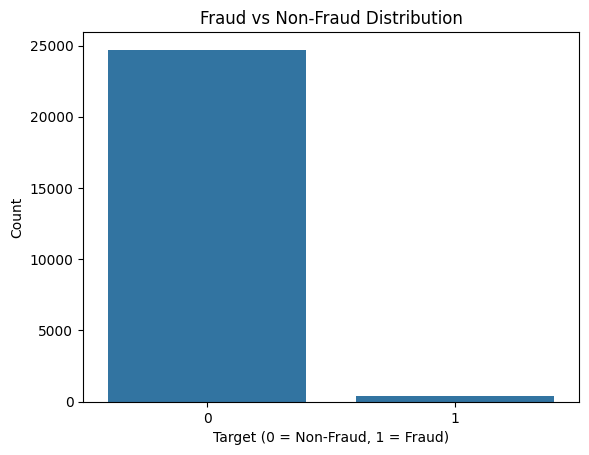

In [100]:
#Fraud Count
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=merged_df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.xlabel("Target (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

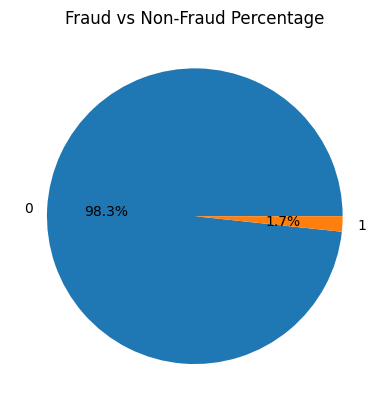

In [101]:
#Fraud Percentage
merged_df['target'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Fraud vs Non-Fraud Percentage")
plt.ylabel('')
plt.show()

####Univariate Analysis

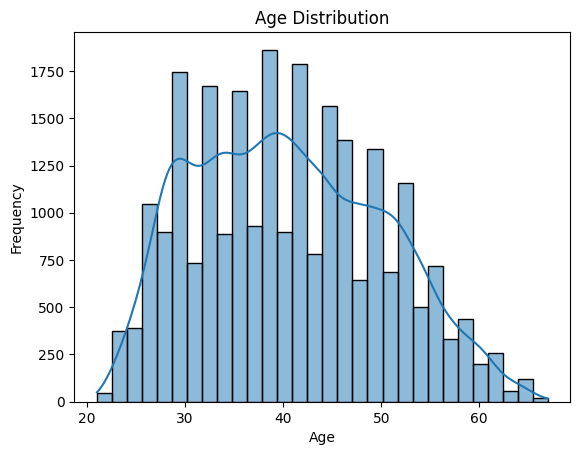

In [102]:
#Age Distribution
sns.histplot(merged_df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

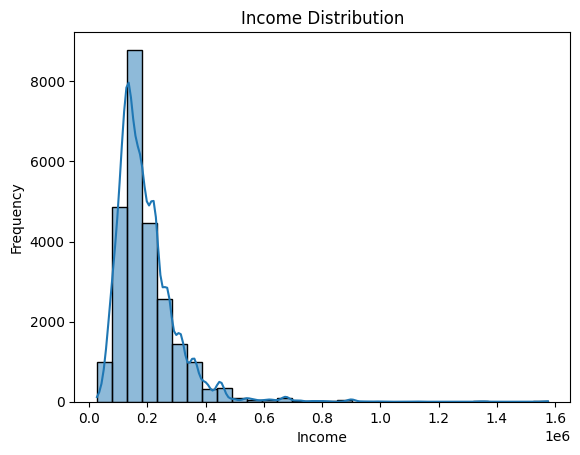

In [103]:
#Income Distribution
sns.histplot(merged_df['income'], bins=30, kde=True)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

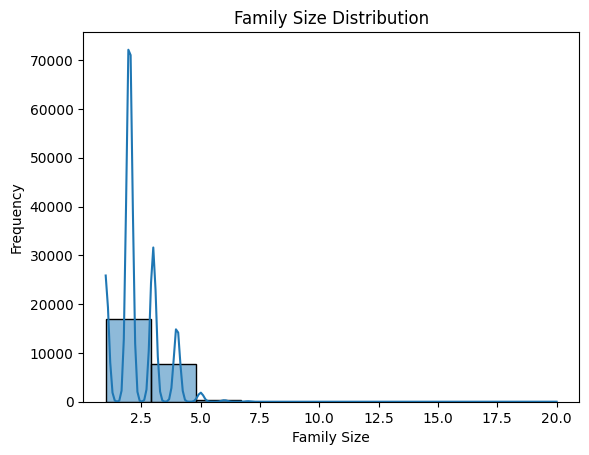

In [104]:
#Family Size Distribution
sns.histplot(merged_df['family_size'], bins=10, kde=True)
plt.title("Family Size Distribution")
plt.xlabel("Family Size")
plt.ylabel("Frequency")
plt.show()

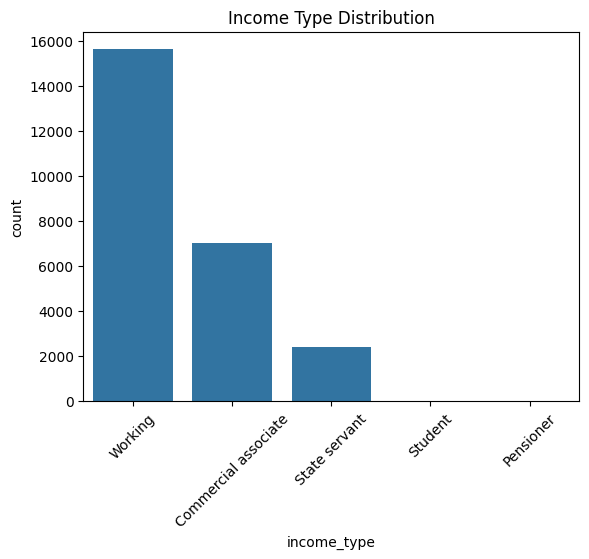

In [105]:


#Income Type Distribution
sns.countplot(x='income_type', data=merged_df)
plt.xticks(rotation=45)
plt.title("Income Type Distribution")
plt.show()

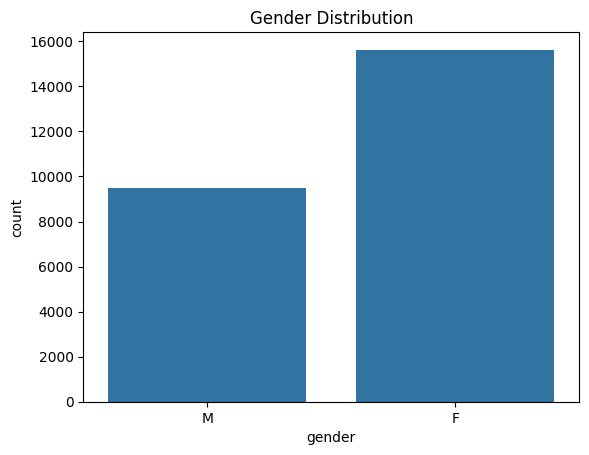

In [106]:
#Gender Distribution
sns.countplot(x='gender', data=merged_df)
plt.title("Gender Distribution")
plt.show()

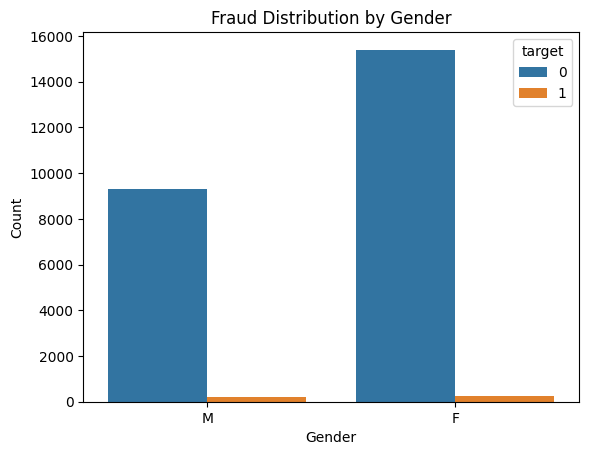

In [111]:
#Gender vs Fraud
sns.countplot(x='gender', hue='target', data=merged_df)
plt.title("Fraud Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

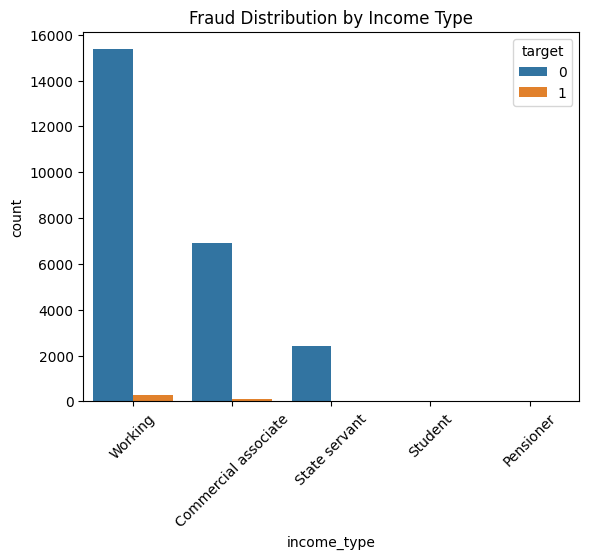

In [112]:
#Income Type vs Fraud
sns.countplot(x='income_type', hue='target', data=merged_df)
plt.xticks(rotation=45)
plt.title("Fraud Distribution by Income Type")
plt.show()

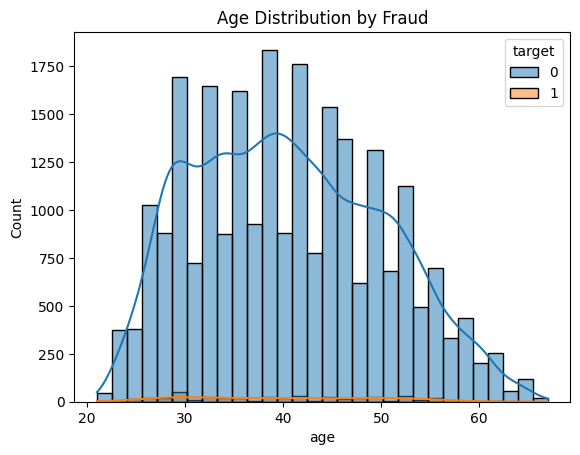

In [113]:
#Age vs Fraud
sns.histplot(data=merged_df, x='age', hue='target', bins=30, kde=True)
plt.title("Age Distribution by Fraud")
plt.show()

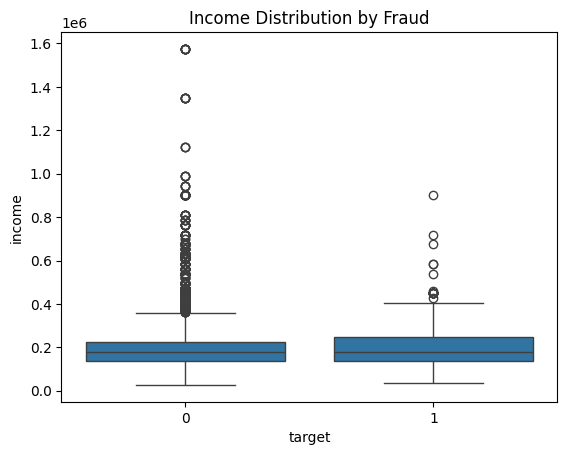

In [110]:
#Income vs Fraud
sns.boxplot(x='target', y='income', data=merged_df)
plt.title("Income Distribution by Fraud")
plt.show()

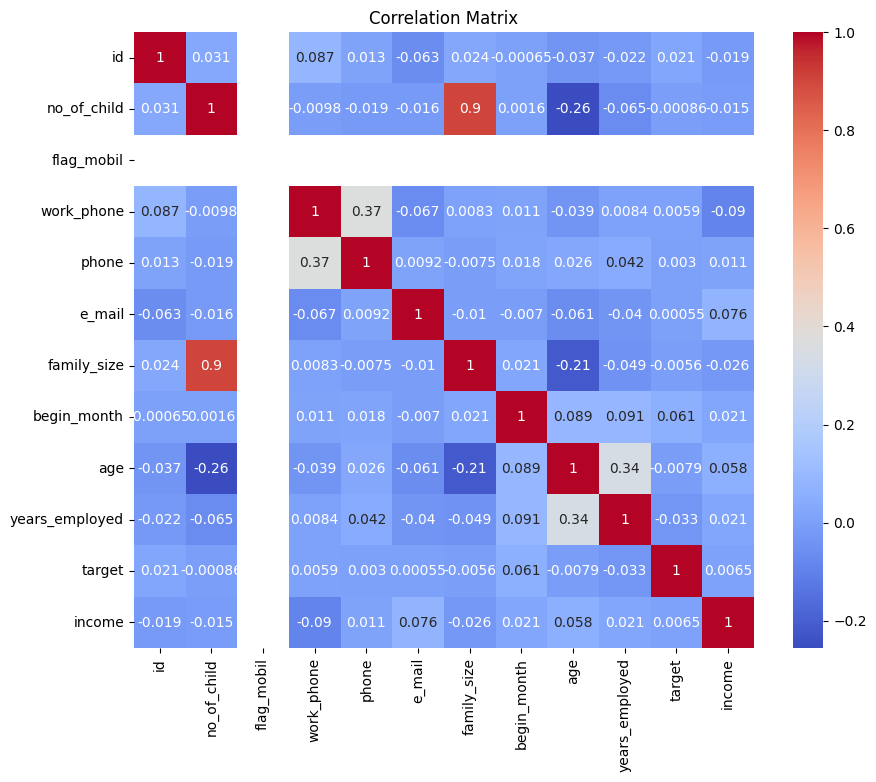

In [116]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(merged_df.select_dtypes(include=['int64','float64']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

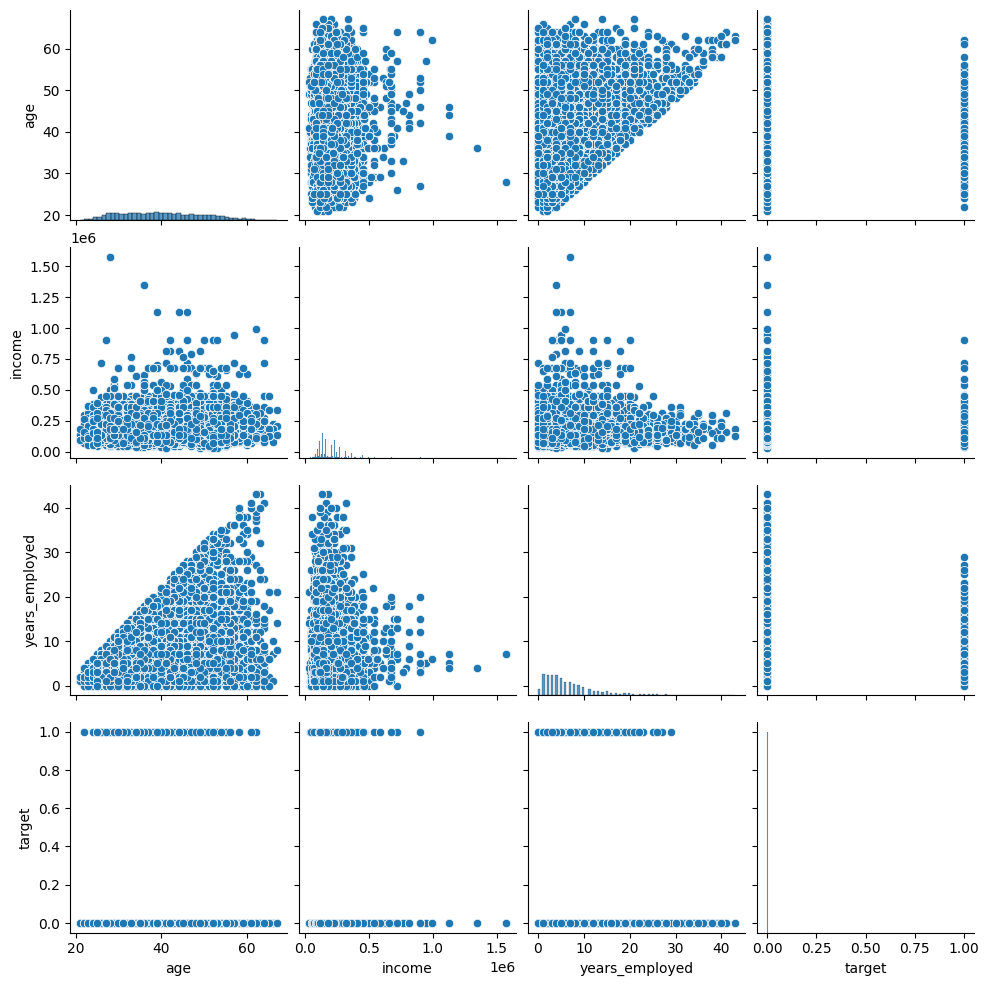

In [118]:
sns.pairplot(merged_df[['age','income','years_employed','target']])

In [ ]:
#Save cleaned dataset
merged_df.to_csv("cleaned_dataset.csv", index=False)